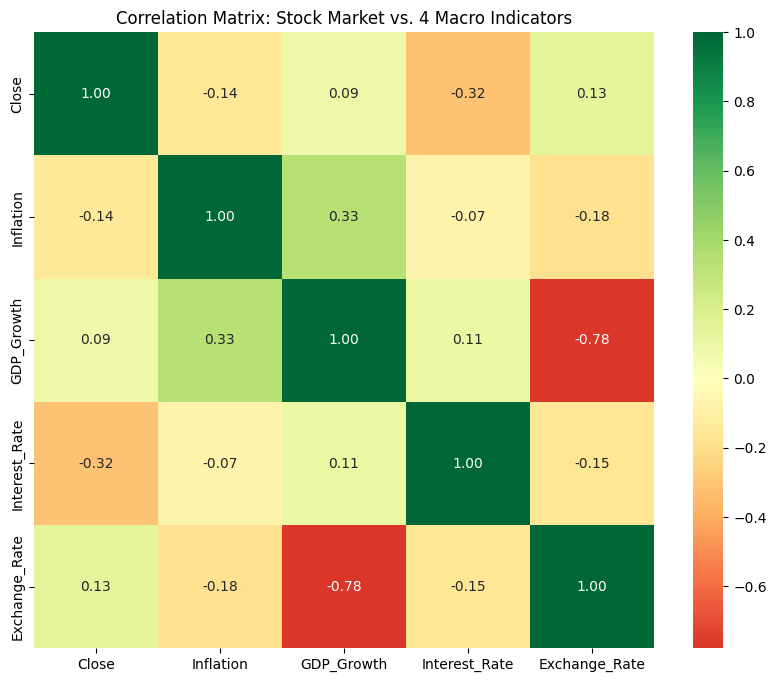

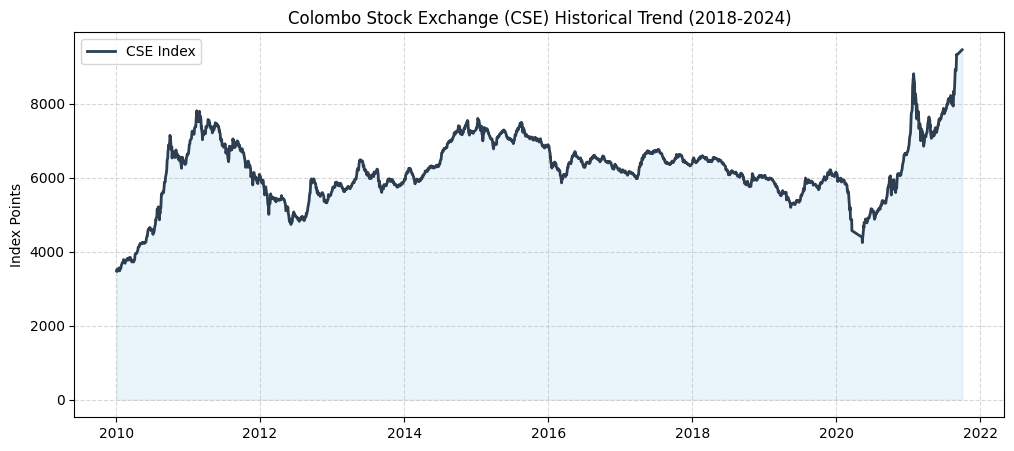

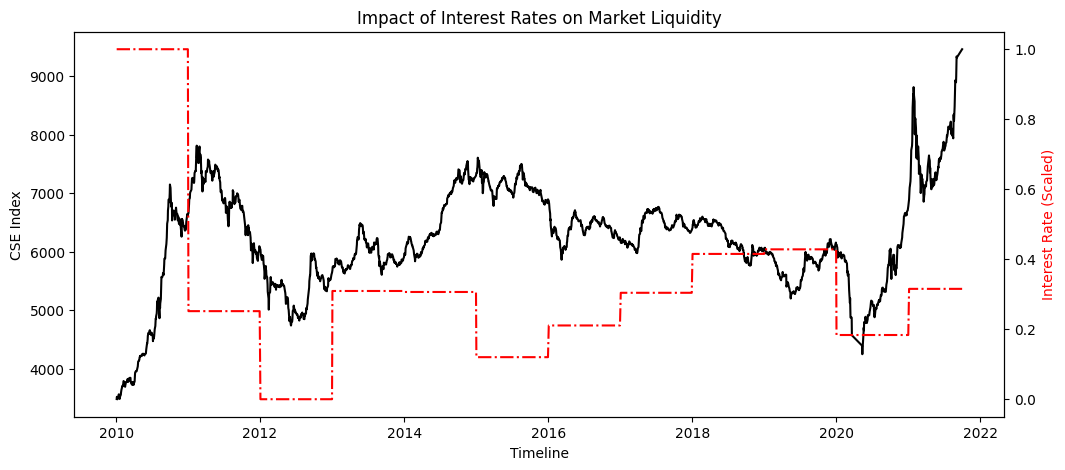

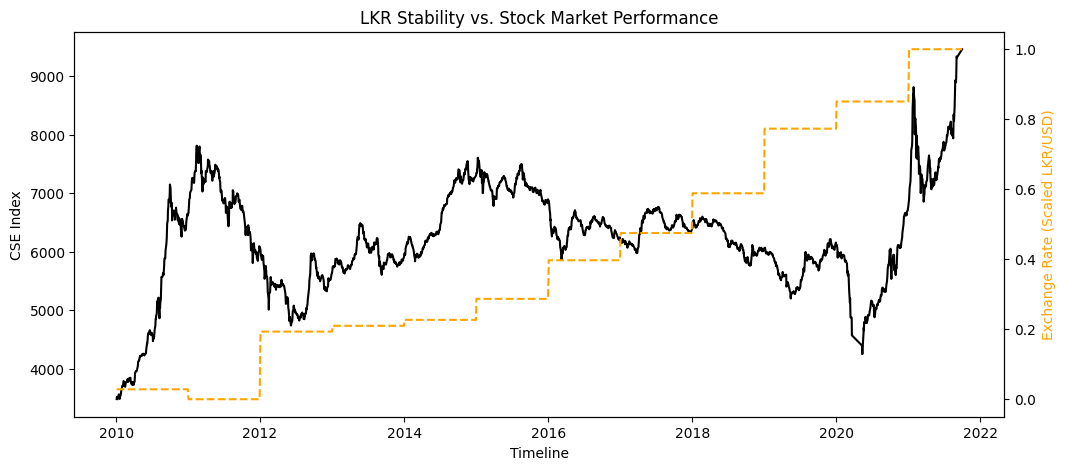

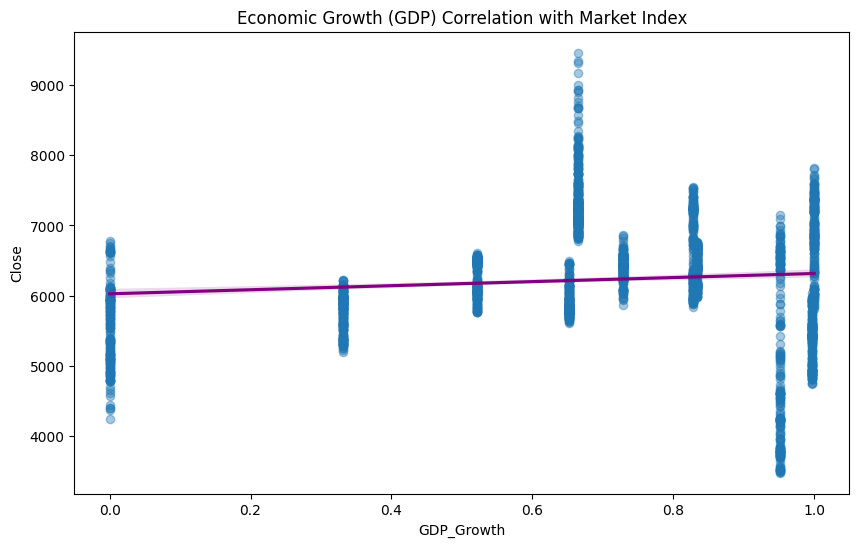

In [13]:
# EDA (Exploratory Data Analysis) Notebook - 4 Indicator Version
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load processed data
df = pd.read_csv('../data/processed/processed_data.csv')

# Ensure Date is datetime for correct time-series plotting
df['Date'] = pd.to_datetime(df['Date'])

# 1. Expanded Correlation Heatmap
plt.figure(figsize=(10, 8))
# Including all 4 macro indicators
cols = ['Close', 'Inflation', 'GDP_Growth', 'Interest_Rate', 'Exchange_Rate']
sns.heatmap(df[cols].corr(), annot=True, cmap='RdYlGn', fmt='.2f', center=0)
plt.title("Correlation Matrix: Stock Market vs. 4 Macro Indicators")
plt.show()

# 2. Market Performance Timeline (The Baseline)
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'], color='#2c3e50', linewidth=2, label='CSE Index')
plt.fill_between(df['Date'], df['Close'], color='#3498db', alpha=0.1)
plt.title("Colombo Stock Exchange (CSE) Historical Trend (2018-2024)")
plt.ylabel("Index Points")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# 3. Interest Rates vs. Stock Price (Inverse Relationship)
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.set_xlabel('Timeline')
ax1.set_ylabel('CSE Index', color='black')
ax1.plot(df['Date'], df['Close'], color='black', label='Stock Price')

ax2 = ax1.twinx()
ax2.set_ylabel('Interest Rate (Scaled)', color='red')
ax2.plot(df['Date'], df['Interest_Rate'], color='red', linestyle='-.', label='Interest Rate')
plt.title("Impact of Interest Rates on Market Liquidity")
plt.show()

# 4. Exchange Rate vs. Stock Price (Currency Impact)
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.set_xlabel('Timeline')
ax1.set_ylabel('CSE Index', color='black')
ax1.plot(df['Date'], df['Close'], color='black')

ax2 = ax1.twinx()
ax2.set_ylabel('Exchange Rate (Scaled LKR/USD)', color='orange')
ax2.plot(df['Date'], df['Exchange_Rate'], color='orange', linestyle='--', label='LKR/USD Rate')
plt.title("LKR Stability vs. Stock Market Performance")
plt.show()

# 5. Scatter Plot: GDP Growth vs. Stock Price
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='GDP_Growth', y='Close', scatter_kws={'alpha':0.4}, line_kws={'color':'purple'})
plt.title("Economic Growth (GDP) Correlation with Market Index")
plt.show()